In [2]:
!pip uninstall pandas-profiling -y
!pip install ydata-profiling

Found existing installation: pandas-profiling 3.2.0
Uninstalling pandas-profiling-3.2.0:
  Successfully uninstalled pandas-profiling-3.2.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.3 MB/s eta 0:00:00
  Attempting uninstall: multimethod
    Found existing installation: multimethod 2.0.2
    Uninstalling multimethod-2.0.2:
      Successfully uninstalled multimethod-2.0.2
  Attempting uninstall: visions
    Found existing installation: visions 0.7.4
    Uninstalling visions-0.7.4:
      Successfully uninstalled visions-0.7.4


In [36]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd
df=pd.read_csv('insurance.csv')

In [8]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [40]:
df['charges'].min()

1121.8739

In [41]:
df['charges'].max()

63770.42801

In [43]:
np.mean(df['charges'])

np.float64(13270.422265141257)

<Axes: xlabel='count', ylabel='smoker'>

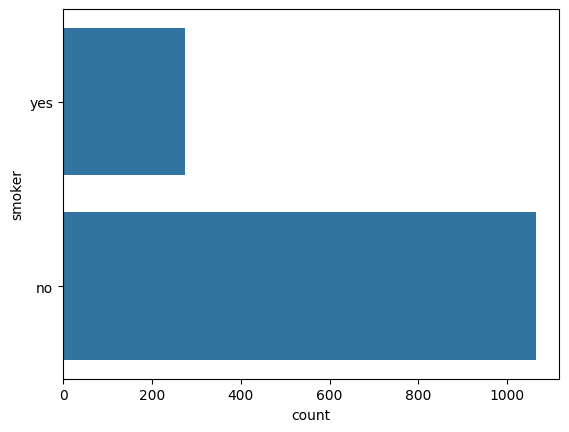

In [37]:
#EDA_univariate analysis
sns.countplot(df['smoker'])

<Axes: xlabel='smoker', ylabel='charges'>

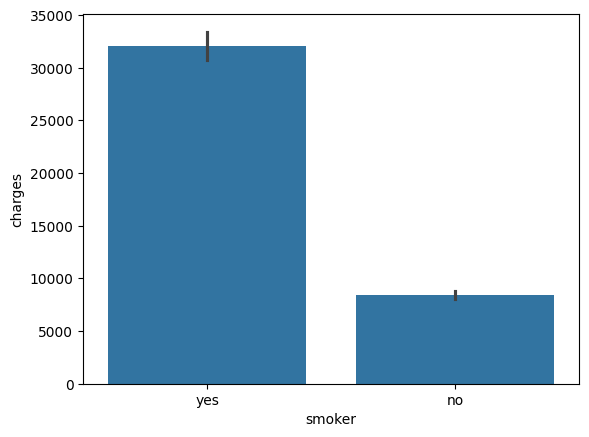

In [38]:
#Bivariate analysis
sns.barplot(x='smoker',y='charges',data=df)        #graph shows strong impact of smoker feature on charges

<Axes: xlabel='age', ylabel='charges'>

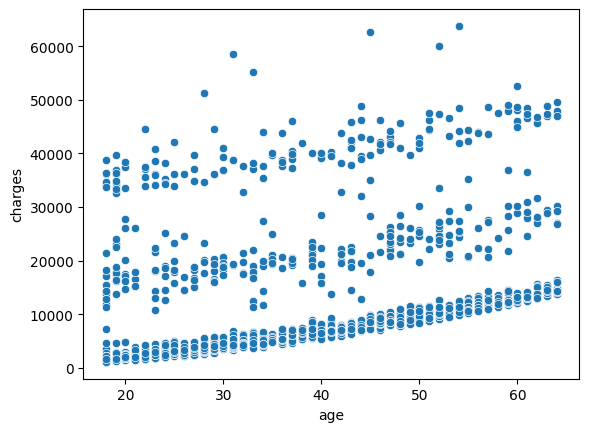

In [61]:
sns.scatterplot(x='age',y='charges',data=df)

<Axes: xlabel='bmi', ylabel='charges'>

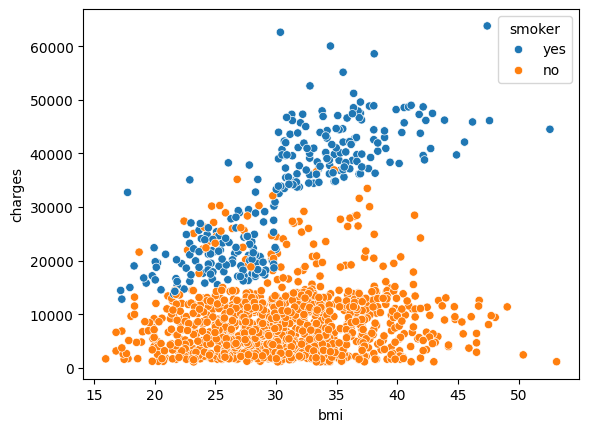

In [63]:
#Multivariate Analysis
sns.scatterplot(x='bmi',y='charges',hue='smoker',data=df)

<Axes: xlabel='region', ylabel='smoker'>

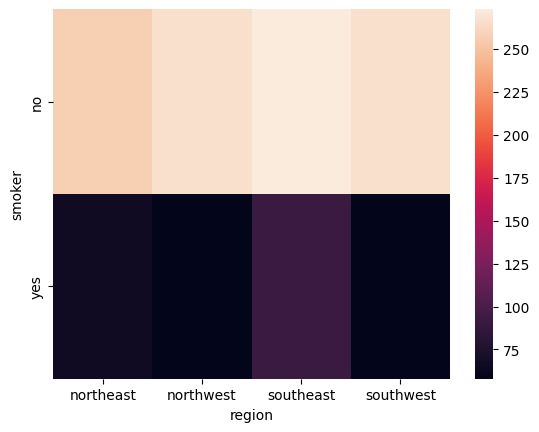

In [65]:
sns.heatmap(pd.crosstab(df['smoker'],df['region']))

<Axes: xlabel='charges', ylabel='Count'>

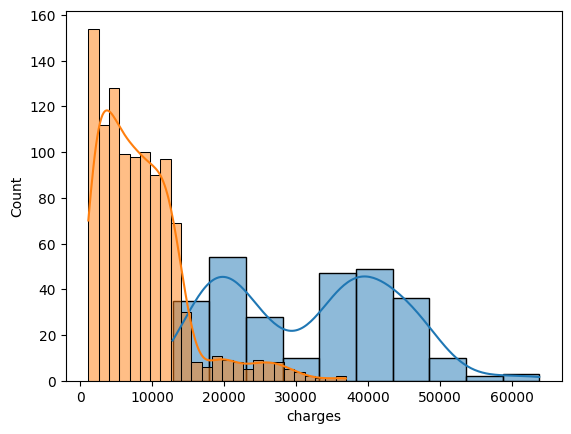

In [67]:
sns.histplot(df[df['smoker']=='yes']['charges'],kde=True)
sns.histplot(df[df['smoker']=='no']['charges'],kde=True)

In [68]:
from ydata_profiling import ProfileReport
profile=ProfileReport(df,title='ydata_profiling_report')
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 7/7 [00:00<00:00, 76.77it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [9]:
categorical=['sex','smoker','region']
numerical=['age','bmi','children']

In [15]:
X=df.drop('charges',axis=1)
Y=df['charges']

In [13]:
preprocessor=ColumnTransformer(
    transformers=[
        ('cat',OneHotEncoder(),categorical),
        ('num',StandardScaler(),numerical)
    ]
)

In [14]:
pipeline=Pipeline(
    [
        ('preprocessing',preprocessor),
        ('model',RandomForestRegressor(
            n_estimators=100,        #built 100 tree and ensemble(average their result)
            random_state=42
        ))
    ]
)

In [18]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [19]:
pipeline.fit(X_train,Y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat', OneHotEncoder(),
                                                  ['sex', 'smoker', 'region']),
                                                 ('num', StandardScaler(),
                                                  ['age', 'bmi',
                                                   'children'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [21]:
Y_prediction=pipeline.predict(X_test)

In [29]:
mse=mean_squared_error(Y_test,Y_prediction)    #gives large value so convert to rmse
rmse=np.sqrt(mse)
print("Root Mean Squared Error: ",rmse)
print("R2 Score: ",r2_score(Y_test,Y_prediction))

Root Mean Squared Error:  4587.723685493877
R2 Score:  0.8644291105492428


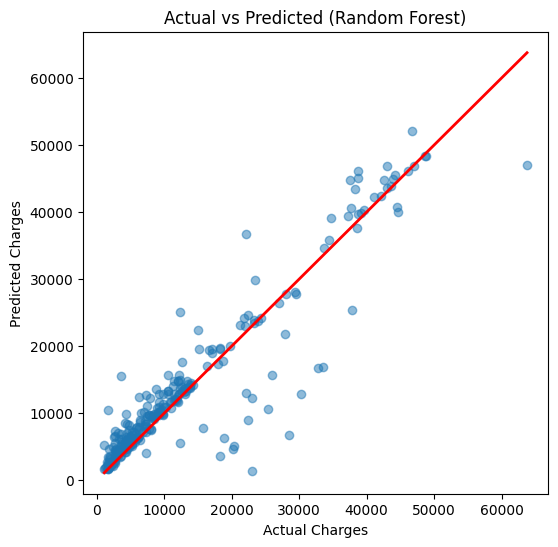

In [57]:
plt.figure(figsize=(6,6))
plt.scatter(Y_test, Y_prediction, alpha=0.5)

# perfect prediction line
plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()],
         color='red', linewidth=2)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

In [31]:
#Get new features names after Encoding
ohe = pipeline.named_steps["preprocessing"].named_transformers_["cat"]
encoded_features = ohe.get_feature_names_out(categorical)

all_features = list(encoded_features) + numerical

In [32]:
#Get importance of each feature(input) in predictions (Higher value->higher imp)
importances = pipeline.named_steps["model"].feature_importances_
# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance)


             Feature  Importance
2          smoker_no    0.431907
9                bmi    0.213362
3         smoker_yes    0.176711
8                age    0.134010
10          children    0.019343
4   region_northeast    0.005385
6   region_southeast    0.004360
1           sex_male    0.004212
5   region_northwest    0.004122
0         sex_female    0.003596
7   region_southwest    0.002991


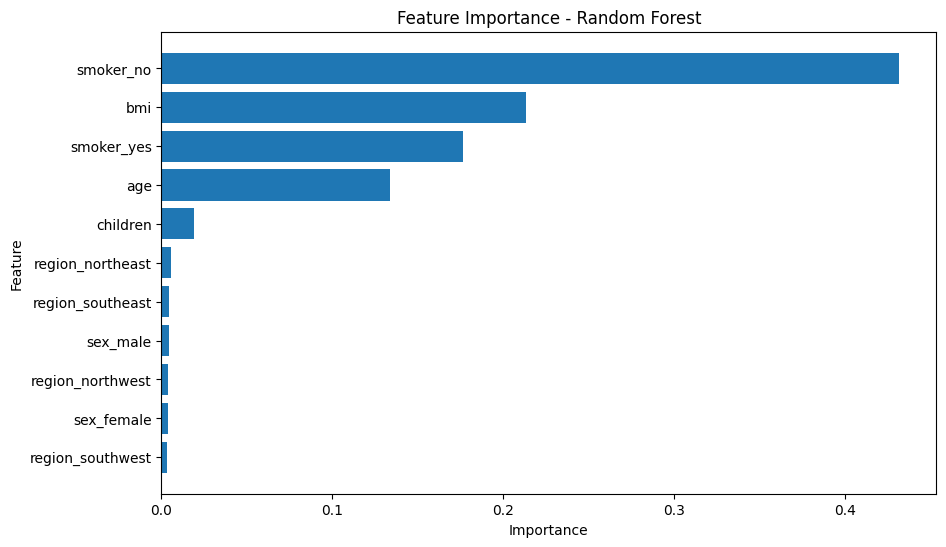

In [35]:
#Showing Feature Importance in graph
plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")
plt.gca().invert_yaxis()              #flips the Y-axis upside down(higher importance features on top)
plt.show()

In [50]:
#Giving new data(labeled) & Testing model performane on new data
new_data = pd.DataFrame([
    {"age": 20, "sex": "female", "bmi": 22.0, "children": 0, "smoker": "no", "region": "northwest"},
    {"age": 50, "sex": "male", "bmi": 35.0, "children": 2, "smoker": "yes", "region": "southeast"},
    {"age": 35, "sex": "male", "bmi": 28.0, "children": 1, "smoker": "no", "region": "southwest"},
    {"age": 60, "sex": "female", "bmi": 31.0, "children": 3, "smoker": "yes", "region": "northeast"},
    {"age": 45, "sex": "male", "bmi": 30.0, "children": 2, "smoker": "no", "region": "southeast"},
    {"age": 28, "sex": "female", "bmi": 25.0, "children": 0, "smoker": "no", "region": "northwest"}
])

newData_predictions = pipeline.predict(new_data)

print(newData_predictions)

[ 2309.736132  42935.0865117  5133.8795258 46275.5047565  8611.133869
  4770.2382979]


In [51]:
#Model performane Test
print("Min prediction:", newData_predictions.min())
print("Max prediction:", newData_predictions.max())
print(df["charges"].describe())

Min prediction: 2309.7361319999986
Max prediction: 46275.50475650002
count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64
